# Dynamic Pricing Analytics for an OTA Client (Online Travel Agency) 

## Hotel Booking & Search Behaviour — Exploratory Data Analysis

- **Role:** Data Analyst
- **Client:** Large OTA platform (MakeMyTrip / Goibibo scale), Tier-2/3 India hotel pricing
- **Handoff:** 4 table extract from the client's Data Engineering team (`dim_hotels`, `dim_customers`, `fact_bookings`, `fact_search_pricing`)

This notebook follows the two source documents:
- `2_ota-project-context.docx` — project brief, team roles, table definitions
- `1_data-cleaning-playbook.docx` — the null handling rule and the table by table cleaning plan

**What this notebook does, in order:**
1. Import & first look at the raw extract
2. Data cleaning, following the playbook rule by rule
3. Exploratory Data Analysis (hotels, customers, bookings, search & pricing)
4. Data driven key insights (data hand off to the Data Scientist)


## 1. Import libraries & read files

The four CSVs are handed off by the client's Data Engineering team (see the project brief, Section 2). 
 We load them with no assumptions about cleanliness yet.

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries loaded.")

Libraries loaded.


In [38]:
# Loading Datasets

customers_df=pd.read_csv("C:\\Users\\troze\\OneDrive\\Desktop\\K\\Imarticus\\EDA (drive, OTA)\\dim_customers.csv")
hotels_df=pd.read_csv("C:\\Users\\troze\\OneDrive\\Desktop\\K\\Imarticus\\EDA (drive, OTA)\\dim_hotels.csv")
bookings_df=pd.read_csv("C:\\Users\\troze\\OneDrive\\Desktop\\K\\Imarticus\\EDA (drive, OTA)\\fact_bookings.csv")
search_pricing_df=pd.read_csv("C:\\Users\\troze\\OneDrive\\Desktop\\K\\Imarticus\\EDA (drive, OTA)\\fact_search_pricing.csv")

print("Customers :" , customers_df.shape )
print("Hotels :" , hotels_df.shape )
print("Bookings : " , bookings_df.shape )
print("Search Pricings : " , search_pricing_df.shape )

Customers : (6000, 10)
Hotels : (300, 15)
Bookings :  (28500, 19)
Search Pricings :  (130000, 10)


## 2. Data Cleaning
##### Referring to data-cleaning-playbook


In [39]:
print("hotels_df:", list(hotels_df.columns))
print()
print("customers_df:", list(customers_df.columns))
print()
print("bookings_df:", list(bookings_df.columns))
print()
print("search_pricing_df:", list(search_pricing_df.columns))

hotels_df: ['Hotel ID', 'Hotel Name', 'city', 'Locality', 'State', 'star_Rating', 'Property Type', 'Total_Rooms', 'Base Price(INR)', 'Review_Score', 'Review_Count', 'Distance_From_Airport_KM', 'Cancellation_Policy', 'Chain', 'Listed_Since']

customers_df: ['cust_id', 'Customer Name', 'Signup_Dt', 'City', 'Loyalty Tier', 'Age Group', 'Preferred Device', 'Gender', 'Acquisition_Channel', 'Preferred_Trip_Type']

bookings_df: ['booking_id', 'hotel_id', 'cust_id', 'Booking Date', 'checkin_date', 'checkout_date', 'Room_Nights', 'Num Rooms', 'Room_Category', 'Meal_Plan', 'Booking_Channel', 'Booking Price(INR)', 'Discount_Applied(%)', 'Net_Amount_Paid(INR)', 'Payment Status', 'Cancellation Flag', 'Refund_Amount(INR)', 'Lead_Time_Days', 'Post_Stay_Rating']

search_pricing_df: ['hotel_id', 'Search_Date', 'Stay Date', 'Device', 'Search_Rank_Position', 'Click_Flag', 'Price Shown(INR)', 'Competitor Avg Price', 'Occupancy Rate(%)', 'Conversion_Flag']


### 2.1 Standardize column names across all four tables

In [40]:
# Correct the column names - lowercase, trim spaces, underscores instead of spaces,
# drop brackets/% so a name like "Booking Price(INR)" becomes booking_price_inr

def clean_cols(cols):
    return (
        cols.str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("(", "_")
        .str.replace(")", "")
        .str.replace("%", "")
        .str.replace("-", "_")
        .str.replace("__", "_")
        .str.strip("_")
    )

customers_df.columns = clean_cols(customers_df.columns)
hotels_df.columns = clean_cols(hotels_df.columns)
bookings_df.columns = clean_cols(bookings_df.columns)
search_pricing_df.columns = clean_cols(search_pricing_df.columns)


In [41]:
print("hotels_df:", list(hotels_df.columns))
print()
print("customers_df:", list(customers_df.columns))
print()
print("bookings_df:", list(bookings_df.columns))
print()
print("search_pricing_df:", list(search_pricing_df.columns))

hotels_df: ['hotel_id', 'hotel_name', 'city', 'locality', 'state', 'star_rating', 'property_type', 'total_rooms', 'base_price_inr', 'review_score', 'review_count', 'distance_from_airport_km', 'cancellation_policy', 'chain', 'listed_since']

customers_df: ['cust_id', 'customer_name', 'signup_dt', 'city', 'loyalty_tier', 'age_group', 'preferred_device', 'gender', 'acquisition_channel', 'preferred_trip_type']

bookings_df: ['booking_id', 'hotel_id', 'cust_id', 'booking_date', 'checkin_date', 'checkout_date', 'room_nights', 'num_rooms', 'room_category', 'meal_plan', 'booking_channel', 'booking_price_inr', 'discount_applied', 'net_amount_paid_inr', 'payment_status', 'cancellation_flag', 'refund_amount_inr', 'lead_time_days', 'post_stay_rating']

search_pricing_df: ['hotel_id', 'search_date', 'stay_date', 'device', 'search_rank_position', 'click_flag', 'price_shown_inr', 'competitor_avg_price', 'occupancy_rate', 'conversion_flag']


In [42]:
print(customers_df.info())
print("="*30)
print(hotels_df.info())
print("="*30)
print(bookings_df.info())
print("="*30)
print(search_pricing_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   cust_id              6000 non-null   object
 1   customer_name        6000 non-null   object
 2   signup_dt            6000 non-null   object
 3   city                 6000 non-null   object
 4   loyalty_tier         3699 non-null   object
 5   age_group            4920 non-null   object
 6   preferred_device     2400 non-null   object
 7   gender               4500 non-null   object
 8   acquisition_channel  6000 non-null   object
 9   preferred_trip_type  3900 non-null   object
dtypes: object(10)
memory usage: 468.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   hotel_id                  300 non-nul

### 2.2 Fix mixed date formats

In [43]:
def parse_two_formats(dates, fmt1, fmt2):
    return pd.to_datetime(dates, format=fmt1, errors="coerce").fillna(
        pd.to_datetime(dates, format=fmt2, errors="coerce")
    )

customers_df["signup_dt"] = parse_two_formats(customers_df["signup_dt"], "%d-%m-%Y", "%Y/%m/%d")
hotels_df["listed_since"] = pd.to_datetime(hotels_df["listed_since"], format="%Y-%m-%d")

bookings_df["booking_date"] = parse_two_formats(bookings_df["booking_date"], "%Y-%m-%d", "%d/%m/%Y")
bookings_df["checkin_date"] = pd.to_datetime(bookings_df["checkin_date"], format="%Y-%m-%d")
bookings_df["checkout_date"] = pd.to_datetime(bookings_df["checkout_date"], format="%Y-%m-%d")

search_pricing_df["search_date"] = pd.to_datetime(search_pricing_df["search_date"], format="%Y-%m-%d")
search_pricing_df["stay_date"] = pd.to_datetime(search_pricing_df["stay_date"], format="%Y-%m-%d")

print("Dates converted")

# signup_dt and booking_date are the only two columns that actually mix two formats, 
# so those two go through parse_two_formats. The other five (listed_since, checkin_date, checkout_date, search_date, stay_date)
# are 100% YYYY-MM-DD with nothing else mixed in, so a plain pd.to_datetime(..., format="%Y-%m-%d")
# is enough — no fmt2 needed, and no dayfirst anywhere since every format here is stated explicitly.

Dates converted


In [44]:
bookings_df["booking_date"]

0       2024-04-30
1       2024-08-21
2       2024-03-07
3       2025-06-21
4       2024-10-18
           ...    
28495   2026-05-20
28496   2024-01-26
28497   2026-04-12
28498   2026-04-26
28499   2024-03-17
Name: booking_date, Length: 28500, dtype: datetime64[ns]

In [45]:
# Now Checking the null values -> info() , isna().sum() and their pcntage as well to apply correct values
# Also checking distrubution

### 2.3 Null handling - per the playbook rule
- <5% null -> mode (categorical) / mean-median (numeric)
- 5-25% null -> lean median for numeric, skewed data is more common than not
- \>25% null + business-critical -> explicit "Missing" category, or a flag column + median fill
- \>25% null + not critical -> drop the column


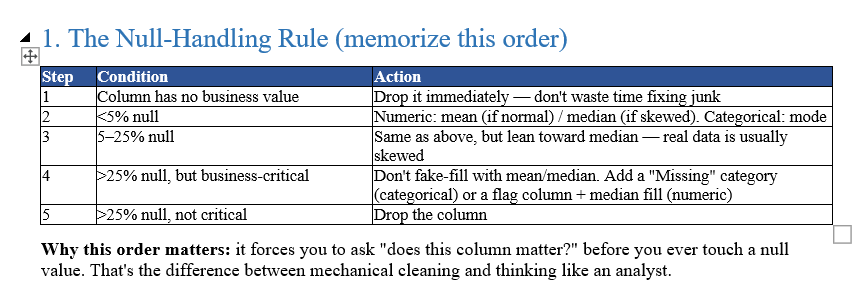

#### 2.3.1 Clean `customers_df`

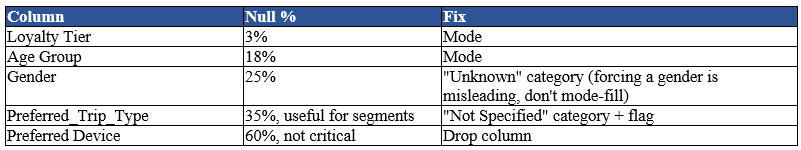

Note that loyalty_tier is 38% not 3%. Hence, we fill the null values with "Missing" Category

In [46]:
(customers_df.isna().sum()/len(customers_df)) *100

cust_id                 0.00
customer_name           0.00
signup_dt               0.00
city                    0.00
loyalty_tier           38.35
age_group              18.00
preferred_device       60.00
gender                 25.00
acquisition_channel     0.00
preferred_trip_type    35.00
dtype: float64

In [47]:
# Null values columns:

null_perctge = ( customers_df.isna().sum() / len(customers_df)  ) * 100 
null_val_cols = null_perctge[ null_perctge > 0 ].index.to_list()
null_val_cols

['loyalty_tier',
 'age_group',
 'preferred_device',
 'gender',
 'preferred_trip_type']

In [48]:
# gender -> "Unknown" (25% null, never mode-fill a demographic)
# loyalty_tier -> "Missing" (>25% null - keep separate from the genuine "None" = not enrolled)
# age_group -> mode (18% null)
# preferred_trip_type -> "Not Specified" + flag (35% null, useful for segments)
# preferred_device -> drop (60% null, not critical for this pricing/conversion project)

customers_df["gender"] = customers_df["gender"].fillna("Unknown")
customers_df["loyalty_tier"] = customers_df["loyalty_tier"].fillna("Missing")
customers_df["age_group"] = customers_df["age_group"].fillna(customers_df["age_group"].mode()[0])

customers_df["trip_type_not_specified"] = customers_df["preferred_trip_type"].isna().astype(int)
customers_df["preferred_trip_type"] = customers_df["preferred_trip_type"].fillna("Not Specified")

customers_df = customers_df.drop(columns=["preferred_device"])

print(customers_df.isna().sum())
print("customers_df has no null values and is good to go")

cust_id                    0
customer_name              0
signup_dt                  0
city                       0
loyalty_tier               0
age_group                  0
gender                     0
acquisition_channel        0
preferred_trip_type        0
trip_type_not_specified    0
dtype: int64
customers_df has no null values and is good to go


In [49]:
### Categorize columns / Check values consistency

# Stable the values -> consistency (SQL also has integrity constraints)
# replace -> unique()

# Check value consistency
# Using `unique()` / `nunique()` first, then fixing with `.replace()` / `.str.title()` where casing or spelling is inconsistent - 
# same idea as a SQL integrity constraint, just done by hand here.

for col in customers_df.columns:
    print(col)
    # print(customers_df[col].unique()) # Too many values, makes jupyter glitch
    print(customers_df[col].nunique())
    print()
    print("*"*80)
    print()

cust_id
6000

********************************************************************************

customer_name
799

********************************************************************************

signup_dt
1092

********************************************************************************

city
36

********************************************************************************

loyalty_tier
8

********************************************************************************

age_group
5

********************************************************************************

gender
3

********************************************************************************

acquisition_channel
6

********************************************************************************

preferred_trip_type
6

********************************************************************************

trip_type_not_specified
2

********************************************************************************



In [50]:
# Fix Casing + merge alternate/historical names into one spelling

customers_df["city"] = customers_df["city"].str.strip().str.title()
customers_df.replace({"city": {
    "Bangalore": "Bengaluru",
    "New Delhi": "Delhi",
    "Benaras": "Varanasi",
    "Bombay": "Mumbai",
    "Calcutta": "Kolkata",
}}, inplace=True)

customers_df["city"].unique()

array(['Rishikesh', 'Shimla', 'Mysuru', 'Lucknow', 'Delhi', 'Bengaluru',
       'Agra', 'Kochi', 'Jaipur', 'Darjeeling', 'Manali', 'Kolkata',
       'Goa', 'Ahmedabad', 'Jodhpur', 'Hyderabad', 'Amritsar', 'Udaipur',
       'Varanasi', 'Pune', 'Mumbai', 'Chennai'], dtype=object)

In [51]:
np.sort(customers_df['city'].unique())

array(['Agra', 'Ahmedabad', 'Amritsar', 'Bengaluru', 'Chennai',
       'Darjeeling', 'Delhi', 'Goa', 'Hyderabad', 'Jaipur', 'Jodhpur',
       'Kochi', 'Kolkata', 'Lucknow', 'Manali', 'Mumbai', 'Mysuru',
       'Pune', 'Rishikesh', 'Shimla', 'Udaipur', 'Varanasi'], dtype=object)

In [52]:
customers_df['loyalty_tier'].unique()

array(['Missing', 'Gold', 'Platinum', 'Silver', 'none', 'GOLD', 'silver',
       'platinum'], dtype=object)

In [53]:
# Fix Casing

customers_df["loyalty_tier"] = customers_df["loyalty_tier"].str.strip().str.title()
customers_df["gender"] = customers_df["gender"].str.strip().str.upper().replace({"M": "Male", "F": "Female"})
customers_df["age_group"] = customers_df["age_group"].str.strip()
customers_df["acquisition_channel"] = customers_df["acquisition_channel"].str.strip()
customers_df["preferred_trip_type"] = customers_df["preferred_trip_type"].str.strip()
customers_df["loyalty_tier"].value_counts(dropna=False)

loyalty_tier
Missing     2301
Silver      1759
Gold        1060
Platinum     709
None         171
Name: count, dtype: int64

In [54]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   cust_id                  6000 non-null   object        
 1   customer_name            6000 non-null   object        
 2   signup_dt                6000 non-null   datetime64[ns]
 3   city                     6000 non-null   object        
 4   loyalty_tier             6000 non-null   object        
 5   age_group                6000 non-null   object        
 6   gender                   6000 non-null   object        
 7   acquisition_channel      6000 non-null   object        
 8   preferred_trip_type      6000 non-null   object        
 9   trip_type_not_specified  6000 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 468.9+ KB


#### 2.3.2 Clean `hotels_df`

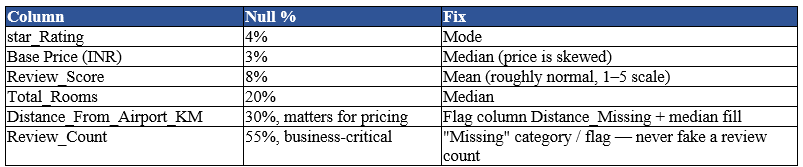

In [55]:
(hotels_df.isna().sum()/len(hotels_df)) *100

hotel_id                     0.0
hotel_name                   0.0
city                         0.0
locality                     0.0
state                        0.0
star_rating                  4.0
property_type                0.0
total_rooms                 20.0
base_price_inr               3.0
review_score                 8.0
review_count                55.0
distance_from_airport_km    30.0
cancellation_policy          0.0
chain                        0.0
listed_since                 0.0
dtype: float64

In [56]:
# Null values columns:

null_pct = ( hotels_df.isna().sum() / len(hotels_df) )*100
null_cols = null_pct[null_pct > 0].index
null_cols

Index(['star_rating', 'total_rooms', 'base_price_inr', 'review_score',
       'review_count', 'distance_from_airport_km'],
      dtype='object')

In [57]:
# star_rating -> mode (4%)
# base_price_inr -> median (3%, skewed)
# review_score -> mean (8%, ~normal)
# total_rooms -> median (20%), distance -> flag + median (30%, matters for pricing)
# review_count -> flag only, never fake a review count (55%, business-critical)

hotels_df["star_rating"] = hotels_df["star_rating"].fillna(hotels_df["star_rating"].mode()[0])
hotels_df["base_price_inr"] = hotels_df["base_price_inr"].fillna(hotels_df["base_price_inr"].median())
hotels_df["review_score"] = hotels_df["review_score"].fillna(hotels_df["review_score"].mean())
hotels_df["total_rooms"] = hotels_df["total_rooms"].fillna(hotels_df["total_rooms"].median())

hotels_df["distance_missing"] = hotels_df["distance_from_airport_km"].isna().astype(int)
hotels_df["distance_from_airport_km"] = hotels_df["distance_from_airport_km"].fillna(
    hotels_df["distance_from_airport_km"].median()
)

hotels_df["review_count_missing"] = hotels_df["review_count"].isna().astype(int)
# review_count itself stays null on purpose

print(hotels_df.drop(columns=["review_count"]).isna().sum())

# hotels_df.drop(columns=["review_count"]) → builds a temporary copy of hotels_df with that one column removed
# .isna().sum() → runs on that temporary copy, counting nulls per remaining column
# The result gets printed
# and then the temporary copy is discarded. hotels_df itself was never reassigned, so it's untouched.
# Basically: we dropped that column without inplace=true so we can count null values in a temp table then removed that table after we got the count
print("customers_df has no null values and is good to go")

hotel_id                    0
hotel_name                  0
city                        0
locality                    0
state                       0
star_rating                 0
property_type               0
total_rooms                 0
base_price_inr              0
review_score                0
distance_from_airport_km    0
cancellation_policy         0
chain                       0
listed_since                0
distance_missing            0
review_count_missing        0
dtype: int64
customers_df has no null values and is good to go


In [58]:
### Categorize columns / Check values consistency

cat_cols = hotels_df.select_dtypes(include="object").columns
print(cat_cols)
print()

for col in cat_cols:
    print(col)
    # print( hotels_df[col].unique()) # Too many values, makes jupyter glitch
    print( hotels_df[col].nunique() )
    print( hotels_df[col].dtype )
    print()
    print( "*"*80 )
    print()

Index(['hotel_id', 'hotel_name', 'city', 'locality', 'state', 'property_type',
       'cancellation_policy', 'chain'],
      dtype='object')

hotel_id
300
object

********************************************************************************

hotel_name
272
object

********************************************************************************

city
35
object

********************************************************************************

locality
63
object

********************************************************************************

state
14
object

********************************************************************************

property_type
10
object

********************************************************************************

cancellation_policy
4
object

********************************************************************************

chain
12
object

********************************************************************************



In [59]:
# Correcting the values in city column

hotels_df.replace( {"city": { 'mumbai':'Mumbai', 'Bangalore':'Bengaluru', 'Calcutta':"Kolkata",
                             'Bombay':"Mumbai", "New Delhi":"Delhi", "Benaras":"Varanasi" , "Bengaluru ":"Bengaluru" ,
                           "New Delhi ":"Delhi" }}, inplace=True)

hotels_df['city'] = hotels_df['city'].str.title()
np.sort( hotels_df['city'].unique() )


array(['Agra', 'Ahmedabad', 'Amritsar', 'Bengaluru', 'Chennai',
       'Darjeeling', 'Delhi', 'Goa', 'Hyderabad', 'Jaipur', 'Jodhpur',
       'Kochi', 'Kolkata', 'Lucknow', 'Manali', 'Mumbai', 'Mysuru',
       'Pune', 'Rishikesh', 'Shimla', 'Udaipur', 'Varanasi'], dtype=object)

In [60]:
# Fix Casing + merge alternate/historical names into one spelling

hotels_df["city"] = hotels_df["city"].str.strip().str.title()
hotels_df["property_type"] = hotels_df["property_type"].str.strip().str.title()
hotels_df["property_type"] = hotels_df["property_type"].replace({"Home-Stay": "Homestay"})  # same category, two spellings
hotels_df["chain"] = hotels_df["chain"].str.strip()
hotels_df["cancellation_policy"] = hotels_df["cancellation_policy"].str.strip().str.title()

hotels_df["city"].unique()

array(['Pune', 'Mumbai', 'Bengaluru', 'Hyderabad', 'Goa', 'Manali',
       'Kochi', 'Agra', 'Shimla', 'Delhi', 'Lucknow', 'Chennai', 'Mysuru',
       'Darjeeling', 'Jaipur', 'Jodhpur', 'Amritsar', 'Kolkata',
       'Varanasi', 'Rishikesh', 'Ahmedabad', 'Udaipur'], dtype=object)

In [61]:
hotels_df.head()

,hotel_id,hotel_name,city,locality,state,star_rating,property_type,total_rooms,base_price_inr,review_score,review_count,distance_from_airport_km,cancellation_policy,chain,listed_since,distance_missing,review_count_missing
0,HTL0001,Sarovar Pune Heights,Pune,Baner,Maharashtra,2.0,Hotel,28.0,7411.0,4.1,8.0,3.8,Flexible,Sarovar,2021-07-15,0,0
1,HTL0002,Sarovar Mumbai Residency,Mumbai,Juhu,Maharashtra,3.0,Hotel,46.0,8815.0,4.7,NaN,0.8,Flexible,Sarovar,2017-09-12,0,1
2,HTL0003,FabHotels Bengaluru Central,Bengaluru,Koramangala,Karnataka,3.0,Guest House,34.0,7919.0,4.7,4.0,8.3,Moderate,FabHotels,2021-07-15,1,0
3,HTL0004,FabHotels Mumbai Heights,Mumbai,Andheri,Maharashtra,5.0,Hotel,58.0,11747.0,4.1,NaN,8.3,Moderate,FabHotels,2016-06-29,1,1
4,HTL0005,Ginger Hyderabad,Hyderabad,Gachibowli,Telangana,3.0,Hotel,50.0,8958.0,3.6,NaN,5.6,Strict,Ginger,2017-01-10,0,1


In [62]:
hotels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   hotel_id                  300 non-null    object        
 1   hotel_name                300 non-null    object        
 2   city                      300 non-null    object        
 3   locality                  300 non-null    object        
 4   state                     300 non-null    object        
 5   star_rating               300 non-null    float64       
 6   property_type             300 non-null    object        
 7   total_rooms               300 non-null    float64       
 8   base_price_inr            300 non-null    float64       
 9   review_score              300 non-null    float64       
 10  review_count              135 non-null    float64       
 11  distance_from_airport_km  300 non-null    float64       
 12  cancellation_policy   

#### 2.3.3 Clean `bookings_df`

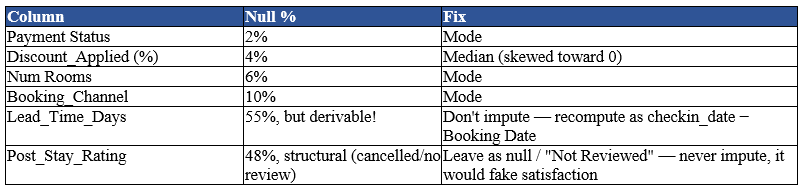

Plus: standardize the flag-like text columns (`cancellation_flag`, `payment_status`, `booking_channel` all arrive with mixed casing / mixed representations), fix mixed date formats, and run the duplicate / outlier / referential-integrity checks the playbook calls for.

In [63]:
(bookings_df.isna().sum()/len(bookings_df)) *100

booking_id              0.000000
hotel_id                0.000000
cust_id                 0.000000
booking_date            0.000000
checkin_date            0.000000
checkout_date           0.000000
room_nights             0.000000
num_rooms               6.000000
room_category           0.000000
meal_plan               0.000000
booking_channel        10.000000
booking_price_inr       0.000000
discount_applied        4.000000
net_amount_paid_inr     0.000000
payment_status          2.000000
cancellation_flag       0.000000
refund_amount_inr       0.000000
lead_time_days         55.000000
post_stay_rating       48.340351
dtype: float64

In [64]:
# Null values columns:

null_pct = ( bookings_df.isna().sum() / len(bookings_df) ) * 100
null_col_ls = null_pct[ null_pct > 0 ].index.to_list()

# has cat and num cols
null_col_ls

['num_rooms',
 'booking_channel',
 'discount_applied',
 'payment_status',
 'lead_time_days',
 'post_stay_rating']

In [65]:
# payment_status -> mode (2%), discount_applied -> median (4%, skewed to 0), num_rooms -> mode (6%)
# booking_channel -> mode (10%), post_stay_rating -> leave null (48%, structural - no stay/no review)
# lead_time_days -> recompute from dates, don't impute (see next cell)

bookings_df["payment_status"] = bookings_df["payment_status"].fillna(bookings_df["payment_status"].mode()[0])
bookings_df["discount_applied"] = bookings_df["discount_applied"].fillna(bookings_df["discount_applied"].median())
bookings_df["num_rooms"] = bookings_df["num_rooms"].fillna(bookings_df["num_rooms"].mode()[0]).astype(int)
bookings_df["booking_channel"] = bookings_df["booking_channel"].fillna(bookings_df["booking_channel"].mode()[0])

# post_stay_rating: no fillna - it's a "Not Reviewed" state, imputing would fake a satisfaction score
print(bookings_df.drop(columns=["post_stay_rating", "lead_time_days"]).isna().sum())

print("bookings_df has no null values and is good to go")

booking_id             0
hotel_id               0
cust_id                0
booking_date           0
checkin_date           0
checkout_date          0
room_nights            0
num_rooms              0
room_category          0
meal_plan              0
booking_channel        0
booking_price_inr      0
discount_applied       0
net_amount_paid_inr    0
payment_status         0
cancellation_flag      0
refund_amount_inr      0
dtype: int64
bookings_df has no null values and is good to go


In [66]:
bookings_df["lead_time_days"] = (bookings_df["checkin_date"] - bookings_df["booking_date"]).dt.days
bookings_df["lead_time_days"]

# lead time (how far ahead the booking was made)

0         0
1        14
2        12
3         3
4        15
         ..
28495     4
28496     1
28497    15
28498     3
28499     6
Name: lead_time_days, Length: 28500, dtype: int64

In [67]:
# cancellation_flag arrives as a mix of N/no/0/No/FALSE and Yes/1/Y/TRUE/yes -> standardize to Yes/No
# Fix Casing + merge alternate/historical names into one spelling

print(sorted(bookings_df["cancellation_flag"].astype(str).unique()))

bookings_df.replace( {'1':'Yes', 'FALSE':'No', '0':'No', 'N':'No', 'Y':"Yes", "TRUE":"Yes" }, inplace=True )
bookings_df['cancellation_flag'] = bookings_df['cancellation_flag'].str.title()
bookings_df["payment_status"] = bookings_df["payment_status"].str.strip().str.title()
bookings_df["booking_channel"] = bookings_df["booking_channel"].str.strip().str.title()
bookings_df["room_category"] = bookings_df["room_category"].str.strip().str.title()
bookings_df["meal_plan"] = bookings_df["meal_plan"].str.strip().str.title()

bookings_df.cancellation_flag.unique()

['0', '1', 'FALSE', 'N', 'No', 'TRUE', 'Y', 'Yes', 'no', 'yes']


array(['No', 'Yes'], dtype=object)

In [68]:
bookings_df.dtypes

booking_id                     object
hotel_id                       object
cust_id                        object
booking_date           datetime64[ns]
checkin_date           datetime64[ns]
checkout_date          datetime64[ns]
room_nights                     int64
num_rooms                       int64
room_category                  object
meal_plan                      object
booking_channel                object
booking_price_inr             float64
discount_applied              float64
net_amount_paid_inr           float64
payment_status                 object
cancellation_flag              object
refund_amount_inr             float64
lead_time_days                  int64
post_stay_rating              float64
dtype: object

In [69]:
### Categorize columns / Check values consistency

bookings_cat_cols = bookings_df.select_dtypes(include="object").columns
print("Bookings cat cols: ", bookings_cat_cols)
print()
bookings_num_cols = bookings_df.select_dtypes(include="number").columns 
print("Bookings num. cols: ", bookings_num_cols)


Bookings cat cols:  Index(['booking_id', 'hotel_id', 'cust_id', 'room_category', 'meal_plan',
       'booking_channel', 'payment_status', 'cancellation_flag'],
      dtype='object')

Bookings num. cols:  Index(['room_nights', 'num_rooms', 'booking_price_inr', 'discount_applied',
       'net_amount_paid_inr', 'refund_amount_inr', 'lead_time_days',
       'post_stay_rating'],
      dtype='object')


In [70]:
for col in bookings_cat_cols:
    print(col)
    print( bookings_df[col].unique() )
    print( bookings_df[col].nunique() )
    print( bookings_df[col].dtype )
    print()
    print("*"*80)
    print()

booking_id
['BKG000001' 'BKG000002' 'BKG000003' ... 'BKG028498' 'BKG028499'
 'BKG028500']
28500
object

********************************************************************************

hotel_id
['HTL0021' 'HTL0017' 'HTL0039' 'HTL0049' 'HTL0146' 'HTL0207' 'HTL0054'
 'HTL0058' 'HTL0214' 'HTL0226' 'HTL0212' 'HTL0201' 'HTL0036' 'HTL0045'
 'HTL0166' 'HTL0271' 'HTL0095' 'HTL0014' 'HTL0260' 'HTL0056' 'HTL0254'
 'HTL0113' 'HTL0044' 'HTL0249' 'HTL0097' 'HTL0199' 'HTL0102' 'HTL0234'
 'HTL0221' 'HTL0137' 'HTL0159' 'HTL0037' 'HTL0280' 'HTL0205' 'HTL0011'
 'HTL0246' 'HTL0167' 'HTL0020' 'HTL0272' 'HTL0066' 'HTL0060' 'HTL0270'
 'HTL0230' 'HTL0236' 'HTL0129' 'HTL0002' 'HTL0163' 'HTL0107' 'HTL0027'
 'HTL0033' 'HTL0065' 'HTL0132' 'HTL0038' 'HTL0141' 'HTL0257' 'HTL0215'
 'HTL0131' 'HTL0185' 'HTL0093' 'HTL0209' 'HTL0082' 'HTL0192' 'HTL0062'
 'HTL0218' 'HTL0098' 'HTL0128' 'HTL0016' 'HTL0265' 'HTL0286' 'HTL0072'
 'HTL0057' 'HTL0171' 'HTL0148' 'HTL0106' 'HTL0161' 'HTL0235' 'HTL0092'
 'HTL0156' 'HTL0196' 'HT

In [71]:
bookings_df['booking_channel'].unique()

array(['App', 'Website', 'Travel Agent', 'Call Center'], dtype=object)

#### 2.3.4 Clean `search_pricing_df`

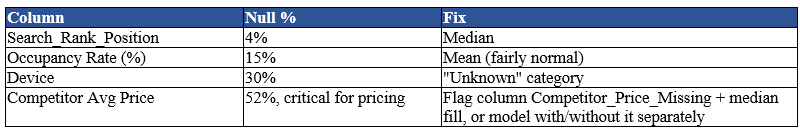

In [72]:
(search_pricing_df.isna().sum()/len(search_pricing_df)) *100

hotel_id                 0.0
search_date              0.0
stay_date                0.0
device                  30.0
search_rank_position     4.0
click_flag               0.0
price_shown_inr          0.0
competitor_avg_price    52.0
occupancy_rate          15.0
conversion_flag          0.0
dtype: float64

In [73]:
# Null values columns:

null_pct = ( search_pricing_df.isna().sum() / len(search_pricing_df) ) * 100
null_val_cols = null_pct[ null_pct > 0 ]
print(null_val_cols)

device                  30.0
search_rank_position     4.0
competitor_avg_price    52.0
occupancy_rate          15.0
dtype: float64


In [74]:
# search_rank_position -> median (4%), occupancy_rate -> mean (15%, ~normal)
# competitor_avg_price -> flag + median (52%, critical for pricing), device -> "Unknown" (30%)

search_pricing_df["search_rank_position"] = search_pricing_df["search_rank_position"].fillna(
    search_pricing_df["search_rank_position"].median()
).astype(int)

# The median happens to land on an exact whole number (5.0), so .astype(int) just strips the trailing .0 , no rows get distorted.
# If the median had come out to something like 4.5, .astype(int) would silently turn every imputed row into 4, not 5

search_pricing_df["occupancy_rate"] = search_pricing_df["occupancy_rate"].fillna(
    search_pricing_df["occupancy_rate"].mean()
)
search_pricing_df["competitor_price_missing"] = search_pricing_df["competitor_avg_price"].isna().astype(int)
search_pricing_df["competitor_avg_price"] = search_pricing_df["competitor_avg_price"].fillna(
    search_pricing_df["competitor_avg_price"].median()
)
search_pricing_df["device"] = search_pricing_df["device"].fillna("Unknown")

print(search_pricing_df.isna().sum())
print("search_pricing_df has no null values and is good to go")

hotel_id                    0
search_date                 0
stay_date                   0
device                      0
search_rank_position        0
click_flag                  0
price_shown_inr             0
competitor_avg_price        0
occupancy_rate              0
conversion_flag             0
competitor_price_missing    0
dtype: int64
search_pricing_df has no null values and is good to go


In [75]:
### Categorize columns / Check values consistency

# check the consistency of values before filling the null values!

cat_cols_sp = search_pricing_df.select_dtypes(include="object").columns

# categorical cols in search pricing!
for col in cat_cols_sp:
    print(col)
    print( search_pricing_df[col].unique() )
    print( search_pricing_df[col].nunique() )
    print()
    print("*"*80)
    print()
    

hotel_id
['HTL0180' 'HTL0011' 'HTL0259' 'HTL0178' 'HTL0067' 'HTL0132' 'HTL0282'
 'HTL0064' 'HTL0086' 'HTL0090' 'HTL0113' 'HTL0291' 'HTL0242' 'HTL0217'
 'HTL0175' 'HTL0079' 'HTL0204' 'HTL0164' 'HTL0122' 'HTL0163' 'HTL0265'
 'HTL0034' 'HTL0238' 'HTL0118' 'HTL0144' 'HTL0219' 'HTL0156' 'HTL0141'
 'HTL0121' 'HTL0222' 'HTL0075' 'HTL0043' 'HTL0295' 'HTL0249' 'HTL0241'
 'HTL0212' 'HTL0091' 'HTL0026' 'HTL0226' 'HTL0083' 'HTL0189' 'HTL0050'
 'HTL0093' 'HTL0267' 'HTL0203' 'HTL0068' 'HTL0268' 'HTL0053' 'HTL0239'
 'HTL0236' 'HTL0149' 'HTL0114' 'HTL0013' 'HTL0199' 'HTL0138' 'HTL0293'
 'HTL0005' 'HTL0250' 'HTL0089' 'HTL0258' 'HTL0145' 'HTL0062' 'HTL0279'
 'HTL0031' 'HTL0123' 'HTL0137' 'HTL0072' 'HTL0252' 'HTL0166' 'HTL0184'
 'HTL0022' 'HTL0254' 'HTL0296' 'HTL0110' 'HTL0142' 'HTL0047' 'HTL0106'
 'HTL0027' 'HTL0237' 'HTL0117' 'HTL0284' 'HTL0081' 'HTL0174' 'HTL0061'
 'HTL0159' 'HTL0147' 'HTL0074' 'HTL0008' 'HTL0096' 'HTL0205' 'HTL0298'
 'HTL0233' 'HTL0012' 'HTL0019' 'HTL0148' 'HTL0299' 'HTL0200' 'HTL019

In [76]:
# device arrives with inconsistent casing (iOS App / IOS APP / ios app etc.) -> map to one spelling
device_map = {
    "ios app": "iOS App",
    "android app": "Android App",
    "desktop web": "Desktop Web",
    "mobile web": "Mobile Web",
}
search_pricing_df["device"] = search_pricing_df["device"].str.strip().str.lower().map(device_map)
search_pricing_df["device"].value_counts(dropna=False)

device
NaN            39000
iOS App        30505
Android App    30174
Mobile Web     15171
Desktop Web    15150
Name: count, dtype: int64

### 2.4 Check for Duplicate Values

In [77]:
print("Duplicate hotel_id           :", hotels_df["hotel_id"].duplicated().sum())
print("Duplicate cust_id            :", customers_df["cust_id"].duplicated().sum())
print("Duplicate booking_id         :", bookings_df["booking_id"].duplicated().sum())
print("Duplicate hotel+cust+checkin :", bookings_df.duplicated(subset=["hotel_id", "cust_id", "checkin_date"]).sum())
print()
print("bookings.hotel_id not in hotels  :", (~bookings_df["hotel_id"].isin(hotels_df["hotel_id"])).sum())
print("bookings.cust_id not in customers:", (~bookings_df["cust_id"].isin(customers_df["cust_id"])).sum())
print("search.hotel_id not in hotels    :", (~search_pricing_df["hotel_id"].isin(hotels_df["hotel_id"])).sum())

Duplicate hotel_id           : 0
Duplicate cust_id            : 0
Duplicate booking_id         : 0
Duplicate hotel+cust+checkin : 0

bookings.hotel_id not in hotels  : 0
bookings.cust_id not in customers: 0
search.hotel_id not in hotels    : 0


In [78]:
print("Cleaning done. Final shapes:")
print("customers_df :", customers_df.shape)
print("hotels_df    :", hotels_df.shape)
print("bookings_df  :", bookings_df.shape)
print("search_pricing_df :", search_pricing_df.shape)

Cleaning done. Final shapes:
customers_df : (6000, 10)
hotels_df    : (300, 17)
bookings_df  : (28500, 19)
search_pricing_df : (130000, 11)


### 2.5 Cleaning Summary

- **Column names** standardized as given across all four tables.
- **Categorical text** (city, device, payment status, etc.) standardized for casing and whitespace (e.g. Bangalore → Bengaluru, Bombay → Mumbai).
- **Flag style columns** cancellation_flag converted from mixed Y/N/0/1/True/False text into Yes/No.
- **Dates** parsed from mixed formats into proper datetime64
- **Nulls** handled per the playbook — mode/median/mean for the low-null columns, explicit "Missing"/"Unknown"/"Not Specified" categories or flag+median for the high-null, business relevant columns, and review_count and post_stay_rating were left null** rather than faked.
- **Duplicates**: none found in booking_id, hotel_id, cust_id
- **Referential integrity**: every hotel_id/cust_id in the fact tables resolves to a real dimension row, in every check, before and after cleaning.


# 3. Data Transformation

day name, month name, year, quarter, weekday/weekend - useful for the seasonality analysis

In [79]:
bookings_df["booking_month"] = bookings_df["booking_date"].dt.month_name()
bookings_df["booking_year"] = bookings_df["booking_date"].dt.year
bookings_df["booking_quarter"] = bookings_df["booking_date"].dt.quarter
bookings_df["booking_dayname"] = bookings_df["booking_date"].dt.day_name()

In [80]:
# Merge all the tables and form a single entity for analysis
# JOINS

# If we still get the null values (ex: after using left join), then that is part of the logic, should be marked as incorrect/unstable value

first_join=pd.merge(left=bookings_df, right=customers_df, how="right", on='cust_id')
first_join

# 47 customers never made a booking,
# so the how="right" join correctly leaves their booking/hotel columns null. That's expected, not a data quality flag.

,booking_id,hotel_id,cust_id,booking_date,checkin_date,checkout_date,room_nights,num_rooms,room_category,meal_plan,...,booking_dayname,customer_name,signup_dt,city,loyalty_tier,age_group,gender,acquisition_channel,preferred_trip_type,trip_type_not_specified
0,BKG007361,HTL0056,CUST00001,2023-11-14,2023-12-02,2023-12-05,3.0,2.0,Deluxe,Full Board,...,Tuesday,Anil Singh,2023-09-25,Rishikesh,Missing,55+,Male,App Install,Solo,0
1,BKG007608,HTL0247,CUST00001,2025-01-03,2025-01-30,2025-02-05,6.0,2.0,Suite,Breakfast Included,...,Friday,Anil Singh,2023-09-25,Rishikesh,Missing,55+,Male,App Install,Solo,0
2,BKG025058,HTL0254,CUST00001,2024-06-14,2024-06-14,2024-06-16,2.0,2.0,Deluxe,Breakfast Included,...,Friday,Anil Singh,2023-09-25,Rishikesh,Missing,55+,Male,App Install,Solo,0
3,BKG012235,HTL0162,CUST00002,2024-10-02,2024-11-08,2024-11-11,3.0,1.0,Premium,Full Board,...,Wednesday,Shreya Kapoor,2024-05-01,Shimla,Missing,45-54,Female,Email Campaign,Family,0
4,BKG017395,HTL0026,CUST00002,2024-02-11,2024-02-18,2024-02-19,1.0,1.0,Deluxe,Room Only,...,Sunday,Shreya Kapoor,2024-05-01,Shimla,Missing,45-54,Female,Email Campaign,Family,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28542,BKG013110,HTL0160,CUST06000,2025-06-17,2025-06-24,2025-06-25,1.0,4.0,Executive,Room Only,...,Tuesday,Vinay Bhat,2024-05-14,Jaipur,Missing,55+,Male,Paid Ads,Solo,0
28543,BKG016072,HTL0258,CUST06000,2024-11-29,2024-11-30,2024-12-03,3.0,1.0,Suite,Breakfast Included,...,Friday,Vinay Bhat,2024-05-14,Jaipur,Missing,55+,Male,Paid Ads,Solo,0
28544,BKG019441,HTL0199,CUST06000,2025-07-13,2025-07-23,2025-07-27,4.0,1.0,Premium,Breakfast Included,...,Sunday,Vinay Bhat,2024-05-14,Jaipur,Missing,55+,Male,Paid Ads,Solo,0
28545,BKG024361,HTL0028,CUST06000,2025-03-27,2025-03-28,2025-03-30,2.0,1.0,Executive,Breakfast Included,...,Thursday,Vinay Bhat,2024-05-14,Jaipur,Missing,55+,Male,Paid Ads,Solo,0


In [81]:
second_join=pd.merge(left=first_join,right=hotels_df,how="left",on='hotel_id')

combined_df= second_join.copy()
combined_df

,booking_id,hotel_id,cust_id,booking_date,checkin_date,checkout_date,room_nights,num_rooms,room_category,meal_plan,...,total_rooms,base_price_inr,review_score,review_count,distance_from_airport_km,cancellation_policy,chain,listed_since,distance_missing,review_count_missing
0,BKG007361,HTL0056,CUST00001,2023-11-14,2023-12-02,2023-12-05,3.0,2.0,Deluxe,Full Board,...,69.0,11354.0,4.600000,NaN,8.3,Moderate,OYO,2020-01-06,1.0,1.0
1,BKG007608,HTL0247,CUST00001,2025-01-03,2025-01-30,2025-02-05,6.0,2.0,Suite,Breakfast Included,...,19.0,9458.0,5.000000,NaN,8.3,Moderate,ITC,2019-01-10,1.0,1.0
2,BKG025058,HTL0254,CUST00001,2024-06-14,2024-06-14,2024-06-16,2.0,2.0,Deluxe,Breakfast Included,...,40.0,9495.0,4.392029,18.0,1.4,Flexible,Radisson,2016-10-16,0.0,0.0
3,BKG012235,HTL0162,CUST00002,2024-10-02,2024-11-08,2024-11-11,3.0,1.0,Premium,Full Board,...,28.0,5264.0,3.900000,178.0,6.2,Flexible,OYO,2016-03-05,0.0,0.0
4,BKG017395,HTL0026,CUST00002,2024-02-11,2024-02-18,2024-02-19,1.0,1.0,Deluxe,Room Only,...,28.0,7260.0,4.600000,38.0,8.3,Moderate,Treebo,2020-08-21,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28542,BKG013110,HTL0160,CUST06000,2025-06-17,2025-06-24,2025-06-25,1.0,4.0,Executive,Room Only,...,46.0,6059.0,4.700000,656.0,0.5,Flexible,OYO,2021-04-22,0.0,0.0
28543,BKG016072,HTL0258,CUST06000,2024-11-29,2024-11-30,2024-12-03,3.0,1.0,Suite,Breakfast Included,...,12.0,6502.0,4.392029,17.0,20.6,Moderate,Lemon Tree,2016-11-21,0.0,0.0
28544,BKG019441,HTL0199,CUST06000,2025-07-13,2025-07-23,2025-07-27,4.0,1.0,Premium,Breakfast Included,...,35.0,7150.0,4.400000,89.0,0.5,Strict,FabHotels,2019-02-24,0.0,0.0
28545,BKG024361,HTL0028,CUST06000,2025-03-27,2025-03-28,2025-03-30,2.0,1.0,Executive,Breakfast Included,...,27.0,8882.0,5.000000,250.0,0.8,Moderate,Treebo,2017-03-04,0.0,0.0


# 4. Data Analysis

With clean tables in hand, we move into the analysis the client actually asked for: understanding pricing, demand, and conversion across the hotel portfolio.

### 4.1 Hotel Portfolio Overview

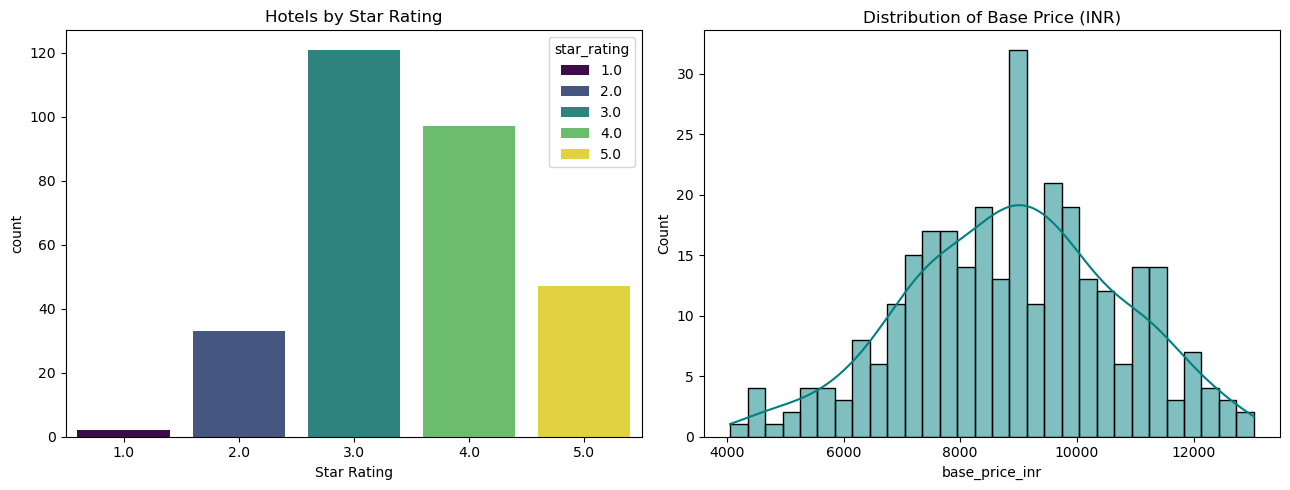

In [82]:
# Univariate Chart (1 -> star_rating)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=hotels_df, x="star_rating", ax=axes[0], hue="star_rating", legend=True, palette="viridis")
axes[0].set_title("Hotels by Star Rating")
axes[0].set_xlabel("Star Rating")


# Univariate Chart (1 -> base_price_inr)
sns.histplot(hotels_df["base_price_inr"], bins=30, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Distribution of Base Price (INR)")
plt.tight_layout()
plt.show()

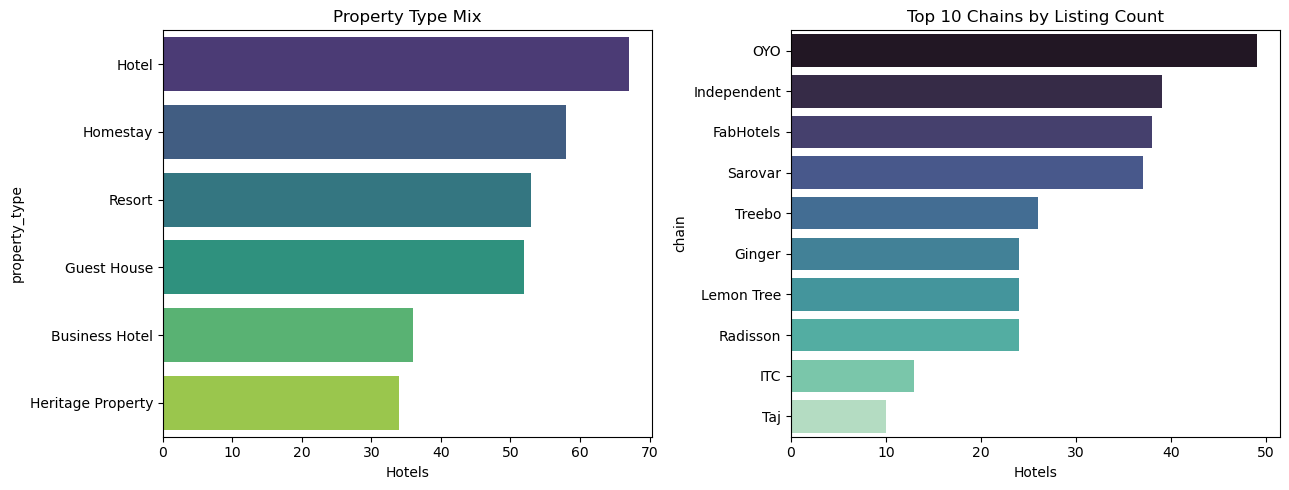

In [83]:
# Univariate Chart (1 -> property_type)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
prop_counts = hotels_df["property_type"].value_counts()
sns.barplot(x=prop_counts.values, y=prop_counts.index, ax=axes[0], hue=prop_counts.index, legend=False, palette="viridis")
axes[0].set_title("Property Type Mix")
axes[0].set_xlabel("Hotels")


# Univariate Chart (1 -> chain)
chain_counts = hotels_df["chain"].value_counts().head(10)
sns.barplot(x=chain_counts.values, y=chain_counts.index, ax=axes[1], hue=chain_counts.index, legend=False, palette="mako")
axes[1].set_title("Top 10 Chains by Listing Count")
axes[1].set_xlabel("Hotels")
plt.tight_layout()
plt.show()

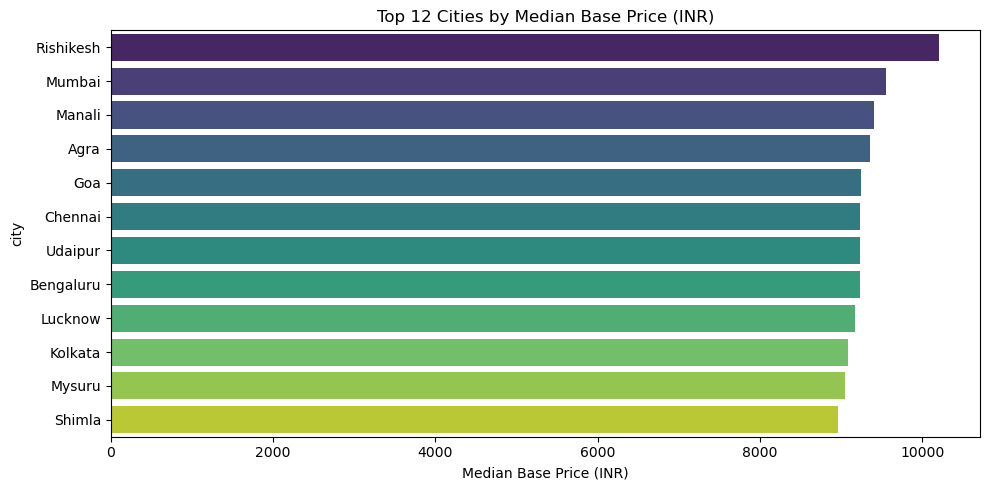

In [84]:
top_price_cities = hotels_df.groupby("city")["base_price_inr"].median().sort_values(ascending=False).head(12)

# Bivariate Chart (2 -> city, base_price_inr) 
# median price by city
plt.figure(figsize=(10, 5))
sns.barplot(x=top_price_cities.values, y=top_price_cities.index, hue=top_price_cities.index, legend=False, palette="viridis")
plt.title("Top 12 Cities by Median Base Price (INR)")
plt.xlabel("Median Base Price (INR)")
plt.tight_layout()
plt.show()

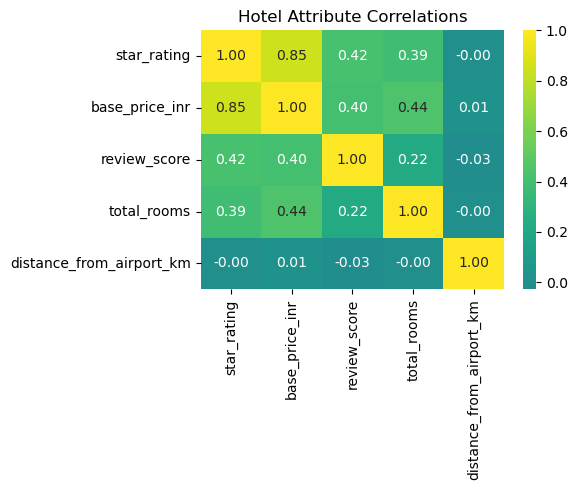

base_price_inr              1.000000
star_rating                 0.849510
total_rooms                 0.439714
review_score                0.399369
distance_from_airport_km    0.009090
Name: base_price_inr, dtype: float64

In [85]:
# Multivariate Chart (5 -> star_rating, base_price_inr, review_score, total_rooms, distance) 
# (Heatmap — correlation matrix)

corr_cols = ["star_rating", "base_price_inr", "review_score", "total_rooms", "distance_from_airport_km"]
corr = hotels_df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='viridis', center=0)
plt.title("Hotel Attribute Correlations")
plt.tight_layout()
plt.show()

corr["base_price_inr"].sort_values(ascending=False)

**Observations:**
- Star rating is by far the strongest driver of base price (r = 0.85)
- Total rooms and review score both have a moderate positive relationship with price (r = 0.40 to 0.44); distance from the airport has essentially no relationship with price (r = 0.01) in this portfolio.
- Standard branded budget and mid market chains (OYO, Independent, FabHotels, Sarovar) dominate listing counts; this is a Tier-2/3 portfolio, not a luxury one.

### 4.2 Customer Base Overview

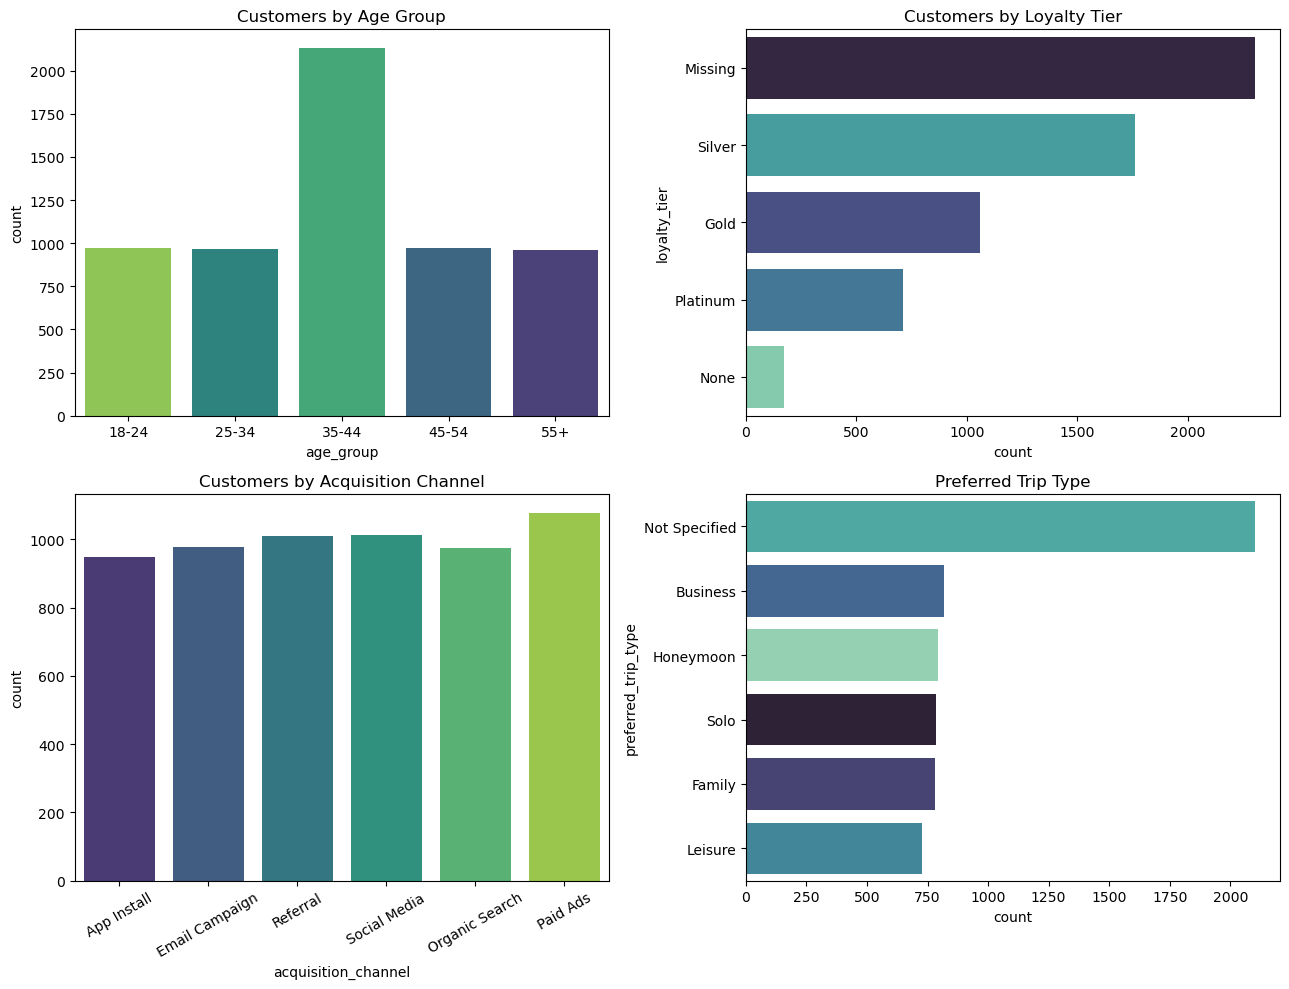

In [86]:
# Univariate Chart (×4) (1 each -> age_group / loyalty_tier / acquisition_channel / preferred_trip_type	)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.countplot(data=customers_df, x="age_group", order=sorted(customers_df["age_group"].unique()),
ax=axes[0, 0], hue="age_group", legend=False, palette="viridis")
axes[0, 0].set_title("Customers by Age Group")


loyalty_order = customers_df["loyalty_tier"].value_counts().index
sns.countplot(data=customers_df, y="loyalty_tier", order=loyalty_order,
         ax=axes[0, 1], hue="loyalty_tier", legend=False, palette="mako")
axes[0, 1].set_title("Customers by Loyalty Tier")


sns.countplot(data=customers_df, x="acquisition_channel", ax=axes[1, 0], hue="acquisition_channel",
              legend=False, palette="viridis")
axes[1, 0].set_title("Customers by Acquisition Channel")
axes[1, 0].tick_params(axis="x", rotation=30)


trip_order = customers_df["preferred_trip_type"].value_counts().index
sns.countplot(data=customers_df, y="preferred_trip_type", order=trip_order,
              ax=axes[1, 1], hue="preferred_trip_type", legend=False, palette="mako")
axes[1, 1].set_title("Preferred Trip Type")


plt.tight_layout()
plt.show()

**Observations:**
- Customers are mostly of the age group 35-44 when seen booking hotels.
- Loyalty members (Silver/Gold/Platinum combined) outnumber the "Missing" segment, so a loyalty tier pricing lever is plausible to test.
- No single trip type dominates, so the pricing model likely needs city or season more than trip type to explain demand (See heatmap, base price depends on star rating)
- Acquistion channels are all roughly comaprable in size, they all show similarity.

### 4.3 Booking & Revenue Analysis

   checkin_date  bookings      revenue
0    2023-09-01       172   8417198.53
1    2023-10-01       701  28379881.99
2    2023-11-01       811  36102989.58
3    2023-12-01       787  34439183.18
4    2024-01-01       832  36716608.00
5    2024-02-01       738  31021969.94
6    2024-03-01       767  31215483.71
7    2024-04-01       859  34166326.95
8    2024-05-01       761  32797823.52
9    2024-06-01       802  34043633.85
10   2024-07-01       792  31632540.69
11   2024-08-01       794  32870944.03
12   2024-09-01       772  30363340.45
13   2024-10-01       837  35258564.50
14   2024-11-01       829  36119643.74
15   2024-12-01       742  31916538.67
16   2025-01-01       804  30579466.27
17   2025-02-01       723  29382628.11
18   2025-03-01       851  40853386.82
19   2025-04-01       778  31675947.59
20   2025-05-01       838  35097797.46
21   2025-06-01       821  31918317.38
22   2025-07-01       818  36665887.66
23   2025-08-01       814  32939888.21
24   2025-09-01       795

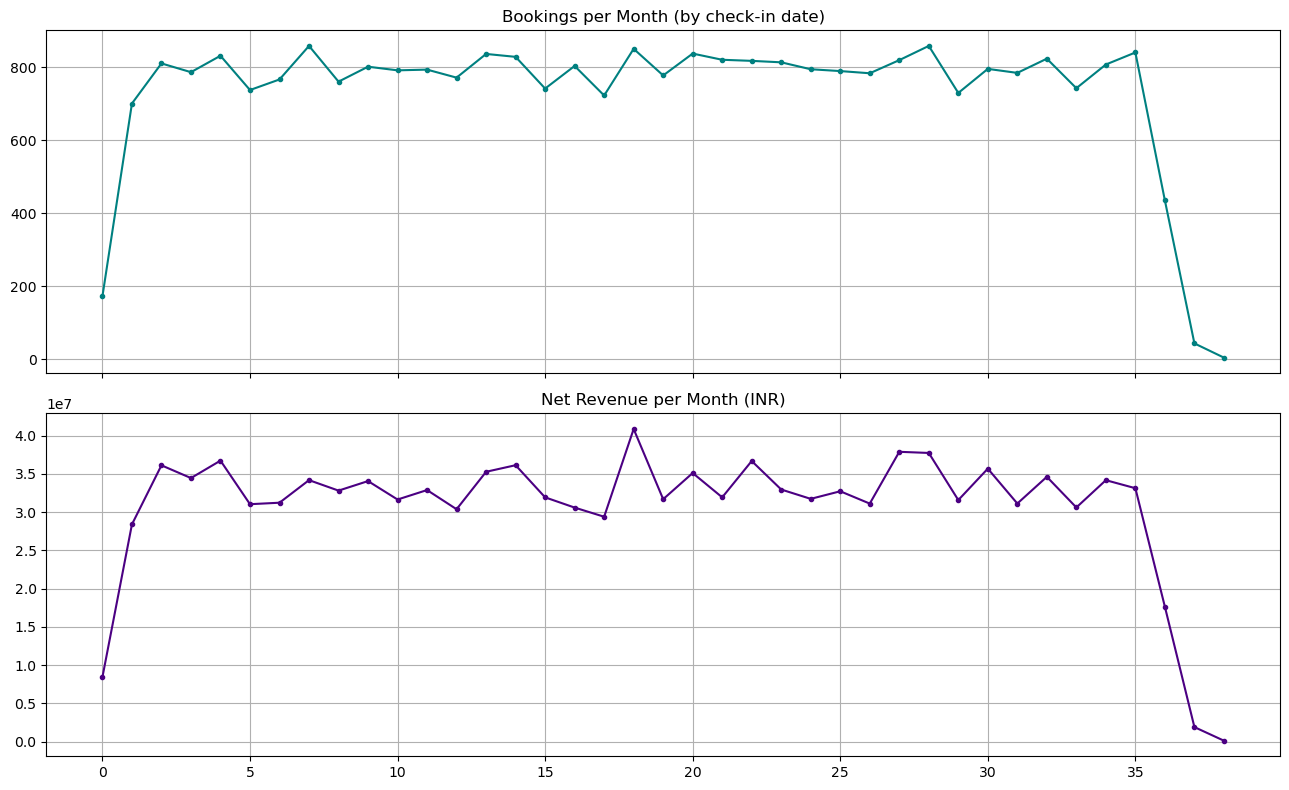

In [87]:
# Bivariate Chart (2 each -> time, metric)
# bookings/revenue over time

monthly = bookings_df.set_index("checkin_date").resample("MS").agg(
    bookings=("booking_id", "count"),
    revenue=("net_amount_paid_inr", "sum")
).reset_index()
print(monthly)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(monthly.index, monthly["bookings"], color="teal", marker="o", markersize=3)
axes[0].set_title("Bookings per Month (by check-in date)")
axes[0].grid(True)
axes[1].plot(monthly.index, monthly["revenue"], color="indigo", marker="o", markersize=3)
axes[1].set_title("Net Revenue per Month (INR)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Observations:**
Revenue and booking volume both show clear month to month swings rather than a flat trend, consistent with the brief's claim of seasonal demand that isnt currently priced for.

               bookings  avg_price
room_category                     
Standard          10023    36478.0
Deluxe             8524    44366.0
Suite              4212    61051.0
Premium            3462    51800.0
Executive          2279    49097.0


<Axes: xlabel='room_category', ylabel='avg_price'>

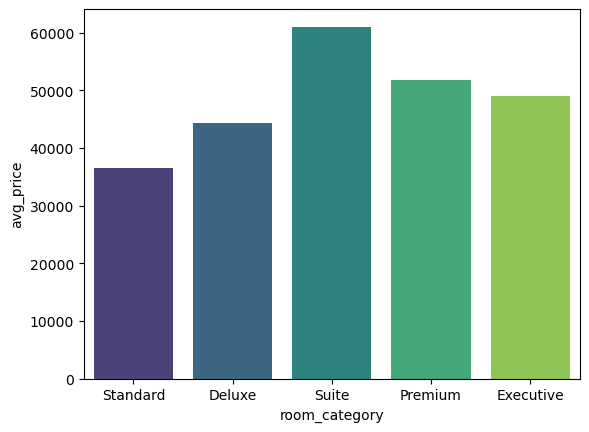

In [88]:
# Bivariate Chart (2 -> room_category, avg_price) 

# Room Stats
room_stats = bookings_df.groupby("room_category").agg(
    bookings=("booking_id", "count"),
    avg_price=("booking_price_inr", "mean")).sort_values("bookings", ascending=False)
room_stats["avg_price"] = room_stats["avg_price"].round(0)
print(room_stats)

sns.barplot(data=room_stats, x='room_category',y='avg_price',hue=room_stats.index,palette="viridis")

**Observations:**
Average booking price for Suite is the highest while standard rooms have lowest prices as compared to the rest of the rooms.

In [89]:
hotel_revenue = bookings_df.groupby("hotel_id").agg(
    bookings=("booking_id", "count"),
    revenue=("net_amount_paid_inr", "sum"),
).join(hotels_df.set_index("hotel_id")[["city", "chain", "star_rating"]])

print("Top 5 hotels by revenue:")
hotel_revenue.sort_values("revenue", ascending=False).head(5)

Top 5 hotels by revenue:


,bookings,revenue,city,chain,star_rating
hotel_id,,,,,
HTL0127,117,7213086.67,Ahmedabad,ITC,5.0
HTL0067,101,7202684.29,Rishikesh,Independent,5.0
HTL0276,115,7081785.70,Amritsar,OYO,4.0
HTL0126,111,7024639.64,Varanasi,Sarovar,5.0
HTL0189,107,6840987.87,Pune,FabHotels,5.0


# 4. Feature Engineering

As per the **data-cleaning-playbook**
 
Consists of new features and proposals built along with the Data Scientist team and and domain experts (like the client's Revenue Manager)

In [90]:
# 1. is_festival_stay - already created in Section 4.3 (bookings_df)

festival_windows = {
    "Diwali":        ["2023-11-12", "2024-10-31", "2025-10-20", "2026-11-08"],
    "Holi":          ["2023-03-08", "2024-03-25", "2025-03-14", "2026-03-04"],
    "Christmas": ["2023-12-25", "2024-12-25", "2025-12-25", "2026-12-25"],
}
WINDOW_DAYS = 3  # +/- days around the festival date counted as "festival period"

festival_dates = set()
for dates in festival_windows.values():
    for d in dates:
        center = pd.Timestamp(d)
        festival_dates.update(pd.date_range(center - pd.Timedelta(days=WINDOW_DAYS),
                                             center + pd.Timedelta(days=WINDOW_DAYS)))

bookings_df["is_festival_stay"] = bookings_df["checkin_date"].isin(festival_dates).astype(int)

daily = bookings_df.groupby(bookings_df["checkin_date"].dt.date).size()
avg_festival_day = daily[daily.index.isin([d.date() for d in festival_dates])].mean()
avg_normal_day = daily[~daily.index.isin([d.date() for d in festival_dates])].mean()

print(f"Avg bookings/day in festival windows : {avg_festival_day:.1f}")
print(f"Avg bookings/day on non-festival days : {avg_normal_day:.1f}")
print(f"Uplift: {(avg_festival_day / avg_normal_day - 1) * 100:+.1f}%")
print()
festival_price = bookings_df.groupby("is_festival_stay")["booking_price_inr"].mean()
print("Avg booking price - non-festival stays:", round(festival_price[0], 0))
print("Avg booking price - festival stays    :", round(festival_price[1], 0))
print(f"Price difference: {(festival_price[1] / festival_price[0] - 1) * 100:+.1f}%")

Avg bookings/day in festival windows : 25.7
Avg bookings/day on non-festival days : 25.1
Uplift: +2.7%

Avg booking price - non-festival stays: 44770.0
Avg booking price - festival stays    : 54780.0
Price difference: +22.4%


In [91]:
# 2. is_weekend_stay - Fri/Sat check-in
bookings_df["is_weekend_stay"] = bookings_df["checkin_date"].dt.dayofweek.isin([4, 5]).astype(int)
bookings_df["is_weekend_stay"]

0        0
1        0
2        0
3        0
4        1
        ..
28495    0
28496    1
28497    0
28498    0
28499    1
Name: is_weekend_stay, Length: 28500, dtype: int64

In [92]:
# 3. days_to_checkin_bucket - non-linear lead time is easier to model in buckets
bookings_df["days_to_checkin_bucket"] = pd.cut(
    bookings_df["lead_time_days"].clip(lower=0),
    bins=[-1, 3, 14, 60, 100000],
    labels=["Last-minute", "Short", "Advance", "Very Early"]
)
bookings_df["days_to_checkin_bucket"]

0        Last-minute
1              Short
2              Short
3        Last-minute
4            Advance
            ...     
28495          Short
28496    Last-minute
28497        Advance
28498    Last-minute
28499          Short
Name: days_to_checkin_bucket, Length: 28500, dtype: category
Categories (4, object): ['Last-minute' < 'Short' < 'Advance' < 'Very Early']

In [93]:
# 4. revenue_per_room_night - normalizes price across stay length & room count
bookings_df["revenue_per_room_night"] = (
    bookings_df["net_amount_paid_inr"] / (bookings_df["room_nights"] * bookings_df["num_rooms"])
)

print("New fact_bookings features:", [c for c in
      ["is_festival_stay", "is_weekend_stay", "days_to_checkin_bucket", "revenue_per_room_night"]])
bookings_df[["is_festival_stay", "is_weekend_stay", "days_to_checkin_bucket", "revenue_per_room_night"]].head()

New fact_bookings features: ['is_festival_stay', 'is_weekend_stay', 'days_to_checkin_bucket', 'revenue_per_room_night']


,is_festival_stay,is_weekend_stay,days_to_checkin_bucket,revenue_per_room_night
0,0,0,Last-minute,17122.631667
1,0,0,Short,8312.400000
2,0,0,Short,10759.245556
3,0,0,Last-minute,14663.274000
4,1,1,Advance,20845.782500


In [94]:
# 5. price_gap_vs_competitor - only meaningful where we trust the competitor price
search_pricing_df["price_gap_vs_competitor"] = np.where(
    search_pricing_df["competitor_price_missing"] == 0,
    (search_pricing_df["price_shown_inr"] - search_pricing_df["competitor_avg_price"]) / search_pricing_df["competitor_avg_price"],
    np.nan
)
search_pricing_df["price_gap_vs_competitor"]

0              NaN
1              NaN
2         0.122156
3        -0.116916
4        -0.035383
            ...   
129995    0.104639
129996         NaN
129997         NaN
129998   -0.049855
129999         NaN
Name: price_gap_vs_competitor, Length: 130000, dtype: float64

In [95]:
# 6. hotel_avg_rating_bucket - simplifies a noisy continuous review_score
hotels_df["hotel_avg_rating_bucket"] = pd.cut(
    hotels_df["review_score"], bins=[0, 3, 4, 5.01],
    labels=["Low", "Medium", "High"]
)
hotels_df["hotel_avg_rating_bucket"] 

0        High
1        High
2        High
3        High
4      Medium
        ...  
295      High
296       Low
297      High
298      High
299      High
Name: hotel_avg_rating_bucket, Length: 300, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [96]:
# 7. city_tier - approximate Tier 1/2/3 mapping (business convention, not an official govt list -
# see the assumptions note in Step 7)
tier_1_cities = {"Mumbai", "Delhi", "Bengaluru", "Chennai", "Kolkata", "Hyderabad", "Pune", "Ahmedabad"}
tier_2_cities = {"Jaipur", "Lucknow", "Kochi", "Amritsar", "Agra", "Varanasi", "Mysuru"}

def city_tier(city):
    if city in tier_1_cities:
        return "Tier 1"
    elif city in tier_2_cities:
        return "Tier 2"
    return "Tier 3"

hotels_df["city_tier"] = hotels_df["city"].apply(city_tier)
customers_df["city_tier"] = customers_df["city"].apply(city_tier)

print(hotels_df["city_tier"].value_counts())

city_tier
Tier 1    107
Tier 2    102
Tier 3     91
Name: count, dtype: int64


In [106]:
# 8. customer_tenure_days - how long a customer had been signed up before this booking
tenure_lookup = customers_df.set_index("cust_id")["signup_dt"]
bookings_df["customer_tenure_days"] = (
    bookings_df["booking_date"] - bookings_df["cust_id"].map(tenure_lookup)
).dt.days

# Same discipline as Step 3 date checks: flag implausible values instead of silently using them
bookings_df["invalid_tenure"] = (bookings_df["customer_tenure_days"] < 0).astype(int)

n_invalid = bookings_df["invalid_tenure"].sum()
print(f"customer_tenure_days negative (booked before signup - a data error): "
      f"{n_invalid} rows ({n_invalid / len(bookings_df) * 100:.1f}%)")
bookings_df["customer_tenure_days"].describe()

customer_tenure_days negative (booked before signup - a data error): 14415 rows (50.6%)


count    28500.000000
mean        -7.328947
std        450.027638
min      -1087.000000
25%       -334.000000
50%         -8.000000
75%        318.000000
max       1079.000000
Name: customer_tenure_days, dtype: float64

# 5. Round-2 EDA on the new features
**As per the playbook**

In [107]:
# Check: price_gap_vs_competitor vs conversion_flag (playbook's own worked example)
gap_check = search_pricing_df.dropna(subset=["price_gap_vs_competitor"])
correlation = gap_check["price_gap_vs_competitor"].corr(gap_check["conversion_flag"])
print(f"Correlation, price_gap_vs_competitor vs conversion_flag: {correlation:.3f}")

Correlation, price_gap_vs_competitor vs conversion_flag: -0.030


Insight: The raw linear correlation is small (0.03), but shows a spread (4.5% to 6.6% conversion). The relationship looks non-linear


In [108]:
# Check: city_tier vs average booking price (group-wise comparison for a categorical feature)
tier_lookup = hotels_df.set_index("hotel_id")["city_tier"]
bookings_df["hotel_city_tier"] = bookings_df["hotel_id"].map(tier_lookup)

tier_price = bookings_df.groupby("hotel_city_tier", observed=True)["booking_price_inr"].mean().round(0)
print(tier_price)

hotel_city_tier
Tier 1    45160.0
Tier 2    45125.0
Tier 3    45798.0
Name: booking_price_inr, dtype: float64


Insight: city_tier does not meaningfully separate booking price in this extract (all three tiers average within 1 to 2% of each other i.e. Rs 45000).

In [109]:
# Check: hotel_avg_rating_bucket vs conversion_flag (a second marginal-feature example, logged either way)
search_hotel_rating = search_pricing_df.merge(hotels_df[["hotel_id", "hotel_avg_rating_bucket"]], on="hotel_id", how="left")
rating_conv = search_hotel_rating.groupby("hotel_avg_rating_bucket", observed=True)["conversion_flag"].mean() * 100
print(rating_conv.round(2))


hotel_avg_rating_bucket
Low       5.44
Medium    5.66
High      5.55
Name: conversion_flag, dtype: float64


Insight: Conversion barely moves across rating buckets (5.4-5.7%)- hotel_avg_rating_bucket is a weak feature, so dont expect it to carry meaningful weight in the model.

## Step 6 — Assumptions & Handoff Notes

As per the project data cleaning playbook:

1. **Representativeness.** This extract is assumed to be a clean, representative historical sample
   per the project brief - not full production volume.
2. **loyalty_tier, "Missing".** The playbook states 3% null; the actual extract is ~38%. Filled
   with an explicit "Missing" category rather than mode, per the >25%-null/business-critical rule.
3. **City normalization** merged Bangalore->Bengaluru, Bombay->Mumbai, Calcutta->Kolkata,
   Benaras->Varanasi, New Delhi->Delhi in both customers_df and hotels_df.
4. **city_tier is our own Tier 1/2/3 grouping**, not an official classification -
   tested in Round 2 EDA.
5. **The right join in Section 3 is expected to produce nulls.** 47 customers never made a booking;
   their booking/hotel columns are null by design, not a data quality flag.
6. **cancellation_flag** was standardized to text Yes/No (not 0/1) - keep this in mind if it
   feeds a model later, since most libraries expect a numeric target.
7. **review_count and post_stay_rating** were deliberately left null, not imputed - filling
   either would fabricate a review count or a satisfaction score the source system never recorded.
8. **price_gap_vs_competitor** kept as a feature despite a weak raw correlation (-0.03) with
    conversion.

---
*End of notebook — Step 1 (Import) through Step 6 (Assumptions) complete, per the data-cleaning-playbook and project brief.*